In [1]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
DATASET_PATH="Ravdess_dataset"

In [4]:
emotion_dict={
    "01":"Neutral","02":"Calm","03":"Happy","04":"Sad",
    "05":"Angry","06":"Fearful","07":"Disgust","08":"Surprised"
}

In [5]:
# Read dataset information
file_paths=[]
emotion_labels=[]
sample_rates=[]
durations=[]

for actor in os.listdir(DATASET_PATH):
    actor_path=os.path.join(DATASET_PATH,actor)
    if not os.path.isdir(actor_path):
        continue
    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            path=os.path.join(actor_path,file)
            emotion=file.split("-")[2]
            file_paths.append(path)
            emotion_labels.append(emotion_dict[emotion])
            y,sr=librosa.load(path,sr=None)
            sample_rates.append(sr)
            durations.append(len(y)/sr)

In [6]:
df_summary =pd.DataFrame({
    "File":file_paths,
    "Emotion":emotion_labels,
    "Duration":durations,
    "SampleRate":sample_rates
})

df_summary.head()

,File,Emotion,Duration,SampleRate
0,Ravdess_dataset\Actor_01\03-01-01-01-01-01-01.wav,Neutral,3.303292,48000
1,Ravdess_dataset\Actor_01\03-01-01-01-01-02-01.wav,Neutral,3.336667,48000
2,Ravdess_dataset\Actor_01\03-01-01-01-02-01-01.wav,Neutral,3.269917,48000
3,Ravdess_dataset\Actor_01\03-01-01-01-02-02-01.wav,Neutral,3.169833,48000
4,Ravdess_dataset\Actor_01\03-01-02-01-01-01-01.wav,Calm,3.536854,48000


In [7]:
class_counts=df_summary["Emotion"].value_counts()
print(class_counts)

Emotion
Calm         192
Happy        192
Sad          192
Angry        192
Fearful      192
Disgust      192
Surprised    192
Neutral       96
Name: count, dtype: int64


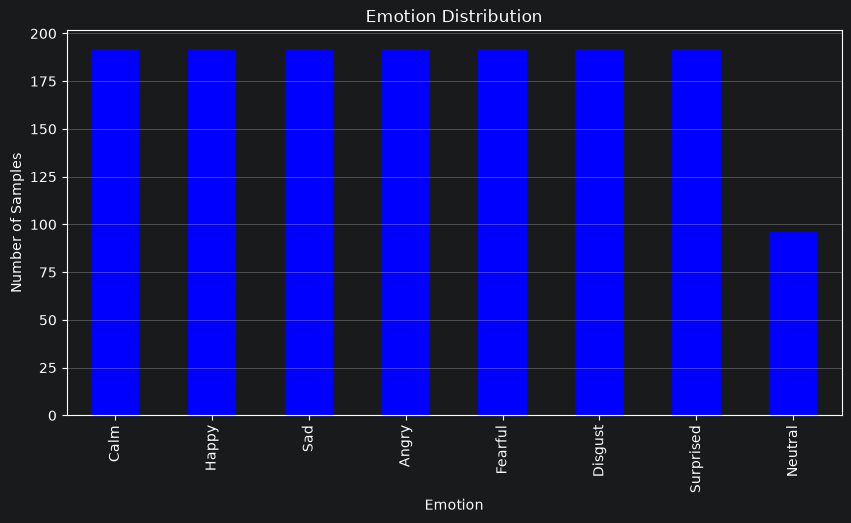

In [9]:
plt.figure(figsize=(10,5))
class_counts.plot(kind="bar",color="blue")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.grid(axis="y")
plt.show()

In [11]:
summary=pd.DataFrame({
    "Emotion":class_counts.index,
    "Samples":class_counts.values
})
print("Emotion and Sample Distribution")
print(summary.head())
plt.figure(figsize=(10,5))
sample_files=[]

for emotion in emotion_dict.values():
    sample_files.append(df_summary[df_summary["Emotion"]==emotion]["File"].iloc[0])


Emotion and Sample Distribution
   Emotion  Samples
0     Calm      192
1    Happy      192
2      Sad      192
3    Angry      192
4  Fearful      192


<Figure size 1000x500 with 0 Axes>

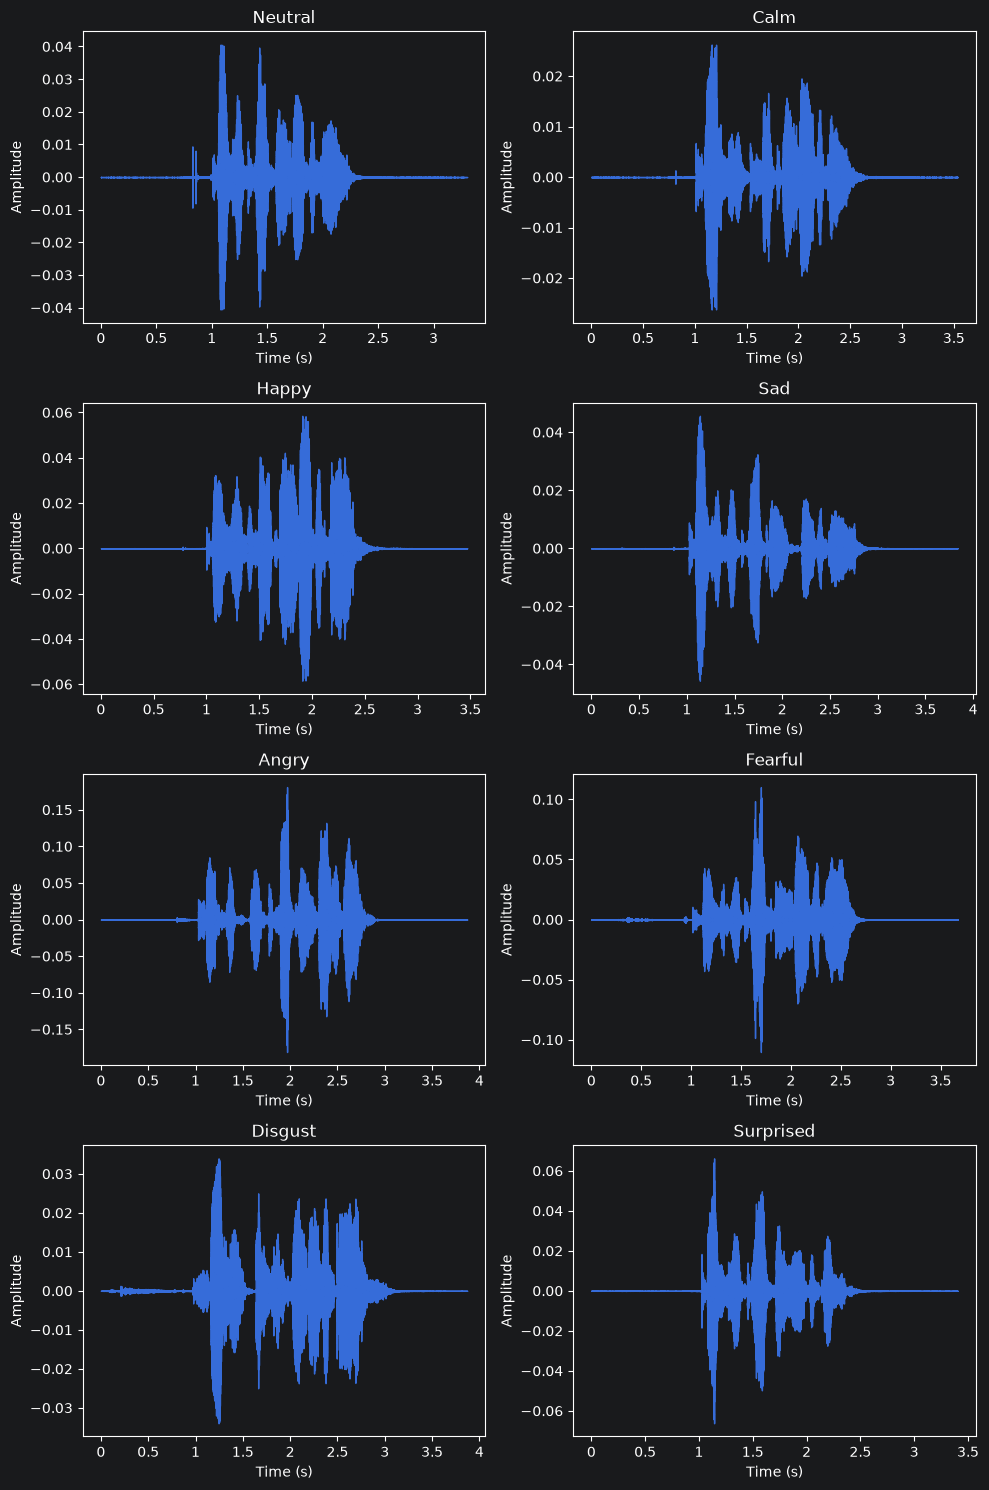

In [13]:
plt.figure(figsize=(10,15))
for i,file in enumerate(sample_files):
    plt.subplot(4,2,i+1)
    y,sr=librosa.load(file,sr=None)
    librosa.display.waveshow(y,sr=sr)
    emotion=df_summary[df_summary["File"]==file]["Emotion"].values[0]
    plt.title(emotion)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

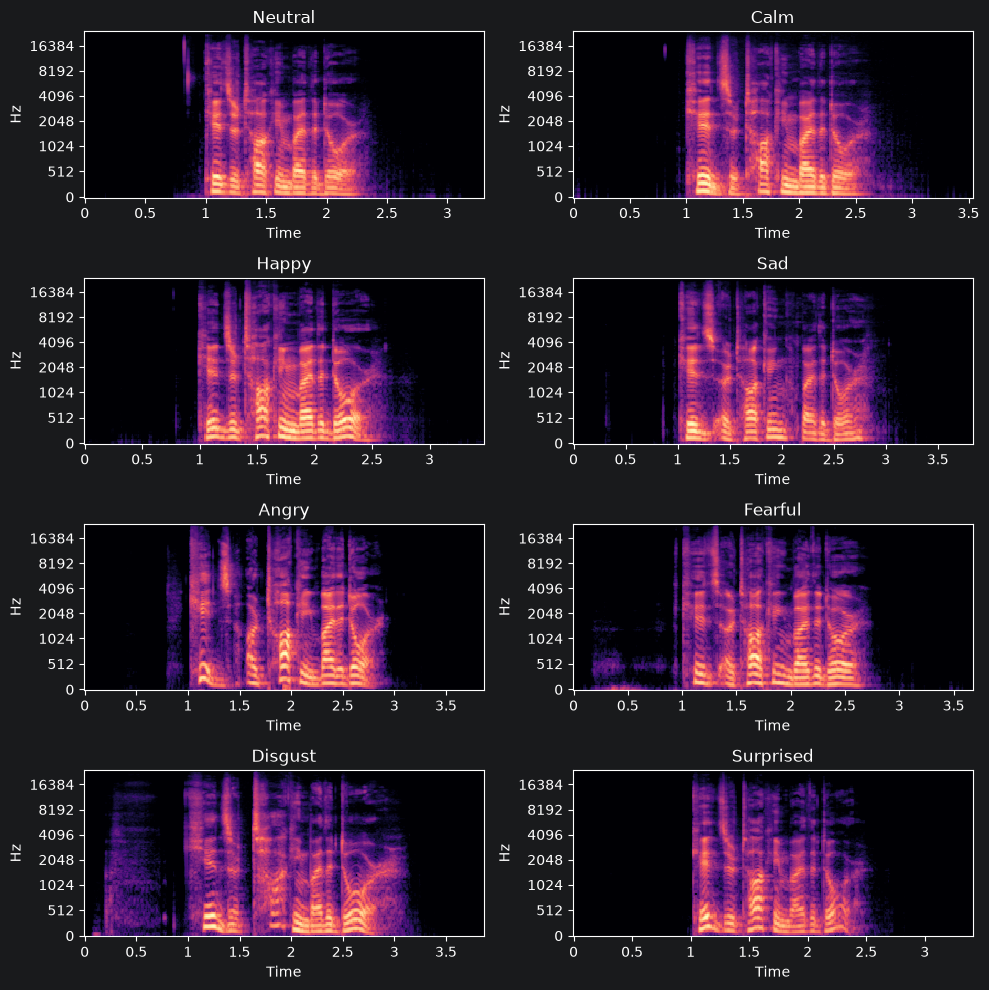

In [17]:
plt.figure(figsize=(10,10))
for i,file in enumerate(sample_files):
    plt.subplot(4,2,i+1)
    y,sr=librosa.load(file,sr=None)
    mel=librosa.feature.melspectrogram(y=y,sr=sr)
    mel_db=librosa.power_to_db(mel,ref=np.max)
    librosa.display.specshow(mel_db,sr=sr,x_axis="time",y_axis="mel")
    emotion=df_summary[df_summary["File"]==file]["Emotion"].values[0]
    plt.title(emotion)

plt.tight_layout()
plt.show()

In [18]:
# Audio Preprocessing
class AudioPreprocessor:
    def __init__(self,sr=16000,n_mfcc=40,target_duration=3.0):
        self.sr=sr
        self.n_mfcc=n_mfcc
        self.target_samples=int(sr*target_duration)

    def load_audio(self,path):
        y,sr=librosa.load(path,sr=self.sr,mono=True)
        return y

    def normalize(self,y):
        return librosa.util.normalize(y)

    def pad_or_truncate(self,y):
        if len(y)<self.target_samples:
            y=np.pad(y,(0,self.target_samples-len(y)))
        else:
            y=y[:self.target_samples]
        return y

    def extract_mfcc(self,y):
        mfcc=librosa.feature.mfcc(y=y,sr=self.sr,n_mfcc=self.n_mfcc)
        return mfcc.T

    def process(self,path):
        y=self.load_audio(path)
        y=self.normalize(y)
        y=self.pad_or_truncate(y)
        mfcc=self.extract_mfcc(y)
        return mfcc

Here we use duration as 3 sec as the dataset has varied duration hence by using the above fixed duration we get sequence of same length

In [19]:
preprocessor=AudioPreprocessor()
#Creating instance and extracting one sample for processing
sample_path=df_summary["File"].iloc[0]

print(sample_path)

Ravdess_dataset\Actor_01\03-01-01-01-01-01-01.wav


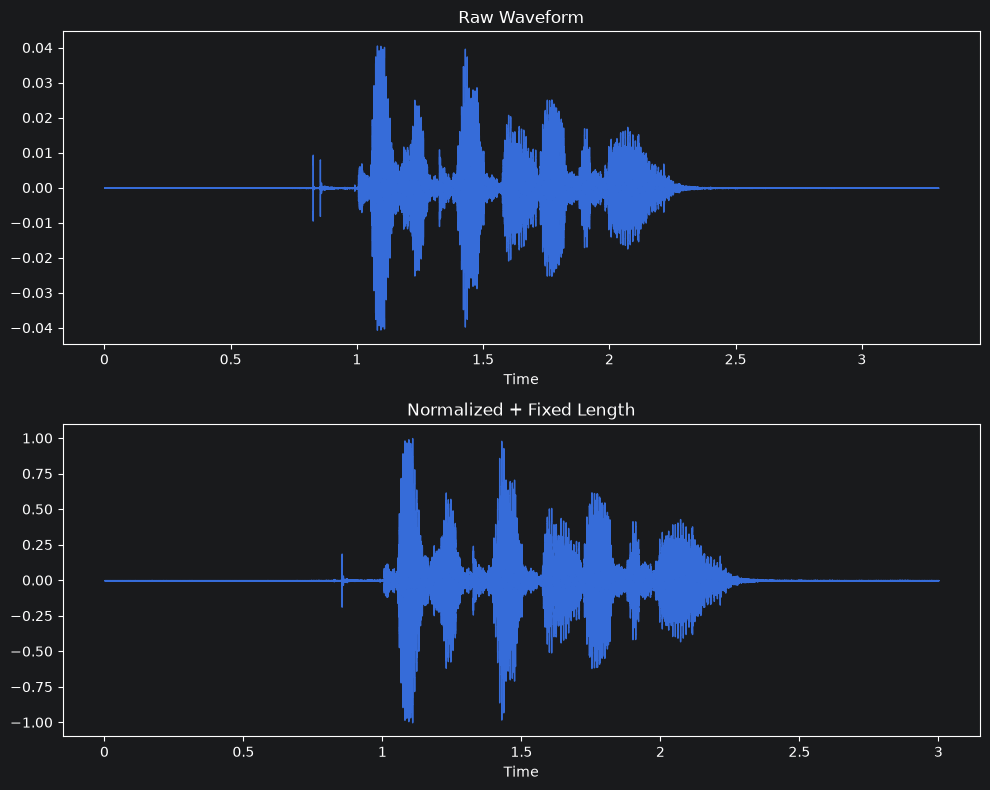

In [22]:
y_og,sr=librosa.load(sample_path,sr=None)

y=preprocessor.load_audio(sample_path)
y=preprocessor.normalize(y)
y=preprocessor.pad_or_truncate(y)

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
librosa.display.waveshow(y_og,sr=sr)
plt.title("Raw Waveform")

plt.subplot(2,1,2)
librosa.display.waveshow(y,sr=preprocessor.sr)
plt.title("Normalized + Fixed Length")

plt.tight_layout()
plt.show()

In [23]:
mfcc=preprocessor.process(sample_path)

print(mfcc.shape)

(94, 40)


Input Shape: (94, 40)


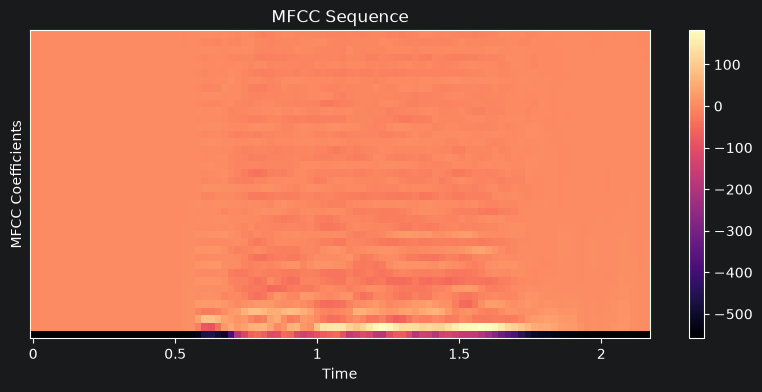

In [26]:
# Visualize Mfcc
mfcc=preprocessor.process(sample_path)
print("Input Shape:",mfcc.shape)
plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc.T,x_axis="time",cmap="magma")

plt.colorbar()
plt.title("MFCC Sequence")
plt.ylabel("MFCC Coefficients")

plt.show()

In [28]:
emotion_names=sorted(df_summary["Emotion"].unique())
label_to_idx={label:i for i,label in enumerate(emotion_names)}
idx_to_label={i:label for label,i in label_to_idx.items()}
print(label_to_idx)

{'Angry': 0, 'Calm': 1, 'Disgust': 2, 'Fearful': 3, 'Happy': 4, 'Neutral': 5, 'Sad': 6, 'Surprised': 7}


In [29]:
df_summary["Label"]=df_summary["Emotion"].map(label_to_idx)

df_summary.head()

,File,Emotion,Duration,SampleRate,Label
0,Ravdess_dataset\Actor_01\03-01-01-01-01-01-01.wav,Neutral,3.303292,48000,5
1,Ravdess_dataset\Actor_01\03-01-01-01-01-02-01.wav,Neutral,3.336667,48000,5
2,Ravdess_dataset\Actor_01\03-01-01-01-02-01-01.wav,Neutral,3.269917,48000,5
3,Ravdess_dataset\Actor_01\03-01-01-01-02-02-01.wav,Neutral,3.169833,48000,5
4,Ravdess_dataset\Actor_01\03-01-02-01-01-01-01.wav,Calm,3.536854,48000,1


In [31]:
# Splitting dataset
from sklearn.model_selection import train_test_split

train_df,temp_df=train_test_split(
    df_summary,
    test_size=0.30,
    random_state=15,
    stratify=df_summary["Label"]
)

val_df,test_df=train_test_split(
    temp_df,
    test_size=0.50,
    random_state=15,
    stratify=temp_df["Label"]
)

print("Training :",len(train_df))
print("Validation :",len(val_df))
print("Testing :",len(test_df))

Training : 1008
Validation : 216
Testing : 216


In [32]:
import torch
from torch.utils.data import Dataset
class EmotionDataset(Dataset):

    def __init__(self,dataframe,preprocessor):
        self.df=dataframe.reset_index(drop=True)
        self.preprocessor=preprocessor

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):
        path=self.df.loc[idx,"File"]
        label=self.df.loc[idx,"Label"]
        mfcc=self.preprocessor.process(path)
        mfcc=torch.tensor(mfcc,dtype=torch.float32)
        label=torch.tensor(label,dtype=torch.long)
        return mfcc,label

In [33]:
train_dataset=EmotionDataset(train_df,preprocessor)

val_dataset=EmotionDataset(val_df,preprocessor)

test_dataset=EmotionDataset(test_df,preprocessor)

In [34]:
from torch.utils.data import DataLoader

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)

val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [38]:
import torch
import torch.nn as nn
class EmotionLSTM(nn.Module):

    def __init__(self,input_size=40,hidden_size=128,num_layers=2,num_classes=8,dropout=0.3):
        super(EmotionLSTM,self).__init__()
        self.lstm=nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc1=nn.Linear(hidden_size,64)
        self.relu=nn.ReLU()
        self.dropout=nn.Dropout(dropout)
        self.fc2=nn.Linear(64,num_classes)

    def forward(self,x):
        output,(hidden,cell)=self.lstm(x)
        x=hidden[-1] # takes n vales
        x=self.fc1(x)
        x=self.relu(x)
        x=self.dropout(x)
        x=self.fc2(x)
        return x


In [40]:
#Creating the model
num_classes=len(emotion_names)

model=EmotionLSTM(num_classes=num_classes)

print(model)

EmotionLSTM(
  (lstm): LSTM(40, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=8, bias=True)
)


In [42]:
# Forward pass
output=model(mfcc)

print(output.shape)

torch.Size([32, 8])


In [43]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [44]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)
print(device)

cpu


In [45]:
# Training
def train_one_epoch(model,loader,criterion,optimizer,device):
    model.train()
    running_loss=0
    correct=0
    total=0
    for mfcc,labels in loader:
        mfcc=mfcc.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        outputs=model(mfcc)

        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()
        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()

    epoch_loss=running_loss/len(loader)
    epoch_acc=100*correct/total

    return epoch_loss,epoch_acc

In [46]:
def validate(model,loader,criterion,device):
    model.eval()
    running_loss=0
    correct=0
    total=0
    with torch.no_grad():
        for mfcc,labels in loader:
            mfcc=mfcc.to(device)
            labels=labels.to(device)
            outputs=model(mfcc)

            loss=criterion(outputs,labels)
            running_loss+=loss.item()
            _,predicted=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(predicted==labels).sum().item()

    epoch_loss=running_loss/len(loader)
    epoch_acc=100*correct/total

    return epoch_loss,epoch_acc

In [48]:
NUM_EPOCHS=10
train_losses=[]
val_losses=[]
train_accs=[]
val_accs=[]
best_val_acc=0
for epoch in range(NUM_EPOCHS):
    train_loss,train_acc=train_one_epoch(
        model,train_loader,
        criterion,optimizer,device)
    val_loss,val_acc=validate(
        model,val_loader,
        criterion,device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc>best_val_acc:
        best_val_acc=val_acc
        torch.save(
            model.state_dict(),
            "best_lstm_model.pth"
        )

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 1/10 | Train Loss: 1.3087 | Train Acc: 52.08% | Val Loss: 1.4919 | Val Acc: 45.37%
Epoch 2/10 | Train Loss: 1.2410 | Train Acc: 55.65% | Val Loss: 1.4936 | Val Acc: 47.22%
Epoch 3/10 | Train Loss: 1.0878 | Train Acc: 60.71% | Val Loss: 1.3727 | Val Acc: 49.07%
Epoch 4/10 | Train Loss: 0.9536 | Train Acc: 64.98% | Val Loss: 1.2589 | Val Acc: 55.09%
Epoch 5/10 | Train Loss: 0.9326 | Train Acc: 65.38% | Val Loss: 1.3203 | Val Acc: 57.87%
Epoch 6/10 | Train Loss: 0.8067 | Train Acc: 69.54% | Val Loss: 1.3649 | Val Acc: 51.39%
Epoch 7/10 | Train Loss: 0.7518 | Train Acc: 73.71% | Val Loss: 1.3565 | Val Acc: 54.63%
Epoch 8/10 | Train Loss: 0.7775 | Train Acc: 73.51% | Val Loss: 1.3587 | Val Acc: 48.61%
Epoch 9/10 | Train Loss: 0.7064 | Train Acc: 76.59% | Val Loss: 1.2619 | Val Acc: 56.02%
Epoch 10/10 | Train Loss: 0.5756 | Train Acc: 81.55% | Val Loss: 1.5204 | Val Acc: 52.31%


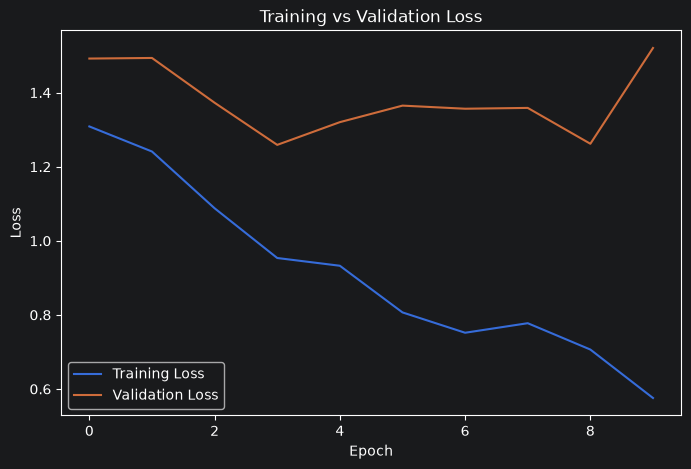

In [50]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Training Loss")
plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

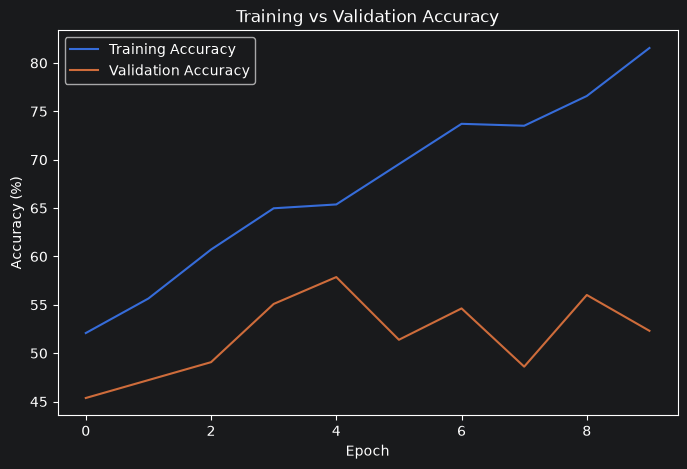

In [51]:
plt.figure(figsize=(8,5))

plt.plot(train_accs,label="Training Accuracy")
plt.plot(val_accs,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

In [52]:
model.eval()

y_true=[]
y_pred=[]

correct_examples=[]
incorrect_examples=[]

with torch.no_grad():

    for mfcc,labels in test_loader:

        mfcc=mfcc.to(device)
        labels=labels.to(device)

        outputs=model(mfcc)

        _,predicted=torch.max(outputs,1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

        for i in range(len(labels)):

            if predicted[i]==labels[i]:

                if len(correct_examples)<3:

                    correct_examples.append(
                        (
                            mfcc[i].cpu(),
                            labels[i].cpu(),
                            predicted[i].cpu()
                        )
                    )

            else:

                if len(incorrect_examples)<3:

                    incorrect_examples.append(
                        (
                            mfcc[i].cpu(),
                            labels[i].cpu(),
                            predicted[i].cpu()
                        )
                    )

In [53]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,classification_report
import seaborn as sns
accuracy=accuracy_score(y_true,y_pred)

precision=precision_score(y_true,y_pred,average="macro")

recall=recall_score(y_true,y_pred,average="macro")

f1=f1_score(y_true,y_pred,average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


Accuracy : 0.5417
Precision: 0.5614
Recall   : 0.5345
F1 Score : 0.5394


In [54]:
print(
    classification_report(y_true,y_pred,
        target_names=emotion_names
    )
)

              precision    recall  f1-score   support

       Angry       0.67      0.41      0.51        29
        Calm       0.77      0.79      0.78        29
     Disgust       0.57      0.59      0.58        29
     Fearful       0.53      0.55      0.54        29
       Happy       0.46      0.45      0.46        29
     Neutral       0.38      0.43      0.40        14
         Sad       0.32      0.48      0.38        29
   Surprised       0.80      0.57      0.67        28

    accuracy                           0.54       216
   macro avg       0.56      0.53      0.54       216
weighted avg       0.57      0.54      0.55       216



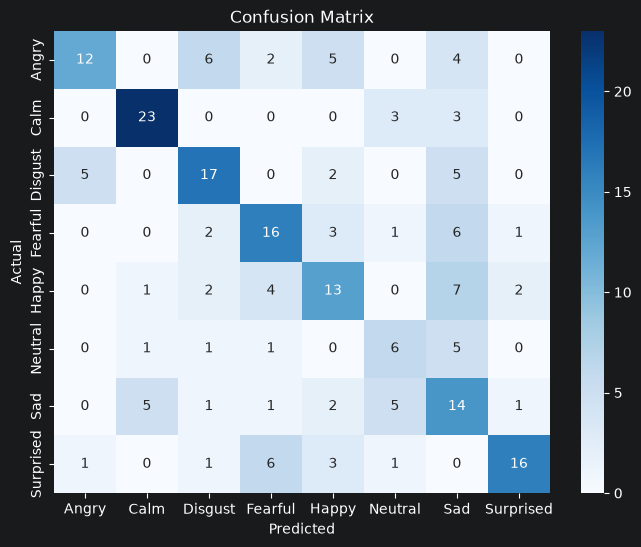

In [55]:
cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()